# SILVA Distributional Equilibrium: Empirical-Measure Lab

This lab derives measure discrepancies, verifies permutation behavior and
masks, runs particle descent, and trains a small task readout from a
distributional SILVA state. The canonical family is
`silva_distributional_deq` [45].

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [45](https://jseluis.github.io/silva-networks/paper/references/#ref-45). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_HOSTED_RUNTIME = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_HOSTED_RUNTIME and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn

from silva_networks import (
    SILVADistributionalDEQ,
    distributional_discrepancy,
    make_variable_measure_dataset,
    silva_equilibrium_model,
)

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(200)

## 1. Matrices Represent Empirical Measures

Input rows $X=(x_1,\ldots,x_M)$ represent

$$
\rho_X=\frac1M\sum_{i=1}^{M}\delta_{x_i}.
$$

Latent rows $Z=(z_1,\ldots,z_N)$ represent

$$
\mu_Z=\frac1N\sum_{j=1}^{N}\delta_{z_j}.
$$

Permuting rows does not change either measure. Padded storage therefore needs
a boolean mask so padding contributes neither to attention nor to empirical
expectations.

In [3]:
data = make_variable_measure_dataset(
    samples=6,
    min_particles=5,
    max_particles=9,
    dimension=2,
    components=2,
    seed=20,
)
assert torch.equal(data.context_mask.sum(dim=1), data.counts)
assert torch.allclose(data.empirical_mean(), data.target_mean)
print("context:", tuple(data.context.shape))
print("particle counts:", data.counts.tolist())
print("target means:", data.target_mean)

context: (6, 9, 2)
particle counts: [6, 5, 7, 8, 9, 5]
target means: tensor([[ 0.6399, -1.3564],
        [-0.0019,  0.8456],
        [-0.6017,  0.1548],
        [ 0.8623, -0.2763],
        [-0.7654,  1.3412],
        [-0.3914, -0.9826]])


## 2. Gaussian MMD and Energy Distance

For kernel $k$, the biased squared maximum mean discrepancy is

$$
\begin{aligned}
\operatorname{MMD}^2(\mu,\nu)
&=\mathbb E_{x,x'\sim\mu}k(x,x')\\
&\quad+\mathbb E_{y,y'\sim\nu}k(y,y')\\
&\quad-2\mathbb E_{x\sim\mu,y\sim\nu}k(x,y).
\end{aligned}
$$

SILVA provides the Gaussian kernel

$$
k_\ell(x,y)=\exp\left(-\frac{\|x-y\|^2}{2\ell^2}\right)
$$

and the energy distance

$$
D_E^2
=2\mathbb E\|x-y\|
-\mathbb E\|x-x'\|
-\mathbb E\|y-y'\|.
$$

In [4]:
permutation = torch.tensor([4, 0, 3, 1, 2, 5, 6, 7, 8])
original = distributional_discrepancy(
    data.context,
    data.context,
    kernel="gaussian",
    left_mask=data.context_mask,
    right_mask=data.context_mask,
)
permuted = distributional_discrepancy(
    data.context,
    data.context[:, permutation],
    kernel="gaussian",
    left_mask=data.context_mask,
    right_mask=data.context_mask[:, permutation],
)
assert torch.allclose(original, permuted, atol=1e-6)
print("self discrepancy:", float(original))
print("permuted discrepancy:", float(permuted))

self discrepancy: 0.0
permuted discrepancy: 0.0


## 3. Distributional SILVA Objective

The transition maps a latent measure and input measure to a transformed latent
measure. The equilibrium objective is

$$
G_{\theta,X}(Z)
=\frac12D^2\left(\mu_Z,\mu_{F_\theta(Z,X)}\right).
$$

Particle descent applies

$$
z_j^{k+1}
=z_j^k-\eta\nabla_{z_j}G_{\theta,X}(Z^k).
$$

For latent permutation $P$ and context permutation $Q$, the built-in
transition satisfies

$$
F_\theta(PZ,QX)=P F_\theta(Z,X).
$$

This is equivariance in latent order and invariance in context order [45].

In [5]:
model = SILVADistributionalDEQ(
    input_dim=2,
    latent_dim=4,
    particles=5,
    heads=2,
    kernel="gaussian",
    bandwidth=1.0,
    step_size=0.12,
    max_iter=3,
)
result = model(
    data.context[:2],
    context_mask=data.context_mask[:2],
    return_result=True,
)
assert result.state.shape == (2, 5, 4)
assert result.discrepancies[-1] <= result.discrepancies[0] + 1e-6
print("discrepancy path:", result.discrepancies)
print("converged to configured tolerance:", result.converged)

discrepancy path: [0.5253183245658875, 0.5223329663276672, 0.49297821521759033, 0.48192647099494934]
converged to configured tolerance: False


## 4. Train a Readout from the Equilibrium Measure

The equilibrium state remains a set. A task head must pool in a way consistent
with the target. Here a pointwise decoder maps latent particles back to two
dimensions, and their mean predicts the empirical input mean:

$$
\widehat m
=\frac1N\sum_{j=1}^{N}Q_\psi(z_j^\star).
$$

In [6]:
decoder = nn.Linear(4, 2)
optimizer = torch.optim.Adam(
    [*model.parameters(), *decoder.parameters()],
    lr=3e-3,
)
losses = []
for epoch in range(4):
    optimizer.zero_grad()
    state = model(data.context, context_mask=data.context_mask)
    decoded_particles = decoder(state)
    prediction = decoded_particles.mean(dim=1)
    task_loss = torch.nn.functional.mse_loss(prediction, data.target_mean)
    transformed = model.transition(
        state,
        data.context,
        context_mask=data.context_mask,
    )
    equilibrium_loss = distributional_discrepancy(
        state,
        transformed,
        kernel="gaussian",
    )
    loss = task_loss + 0.05 * equilibrium_loss
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))

assert all(torch.isfinite(torch.tensor(losses)))
print("training losses:", losses)
print("task loss:", float(task_loss.detach()))
print("distributional discrepancy:", float(equilibrium_loss.detach()))

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


training losses: [0.8673074245452881, 0.8647595047950745, 0.8614999055862427, 0.859478235244751]
task loss: 0.8103713989257812
distributional discrepancy: 0.9821367263793945


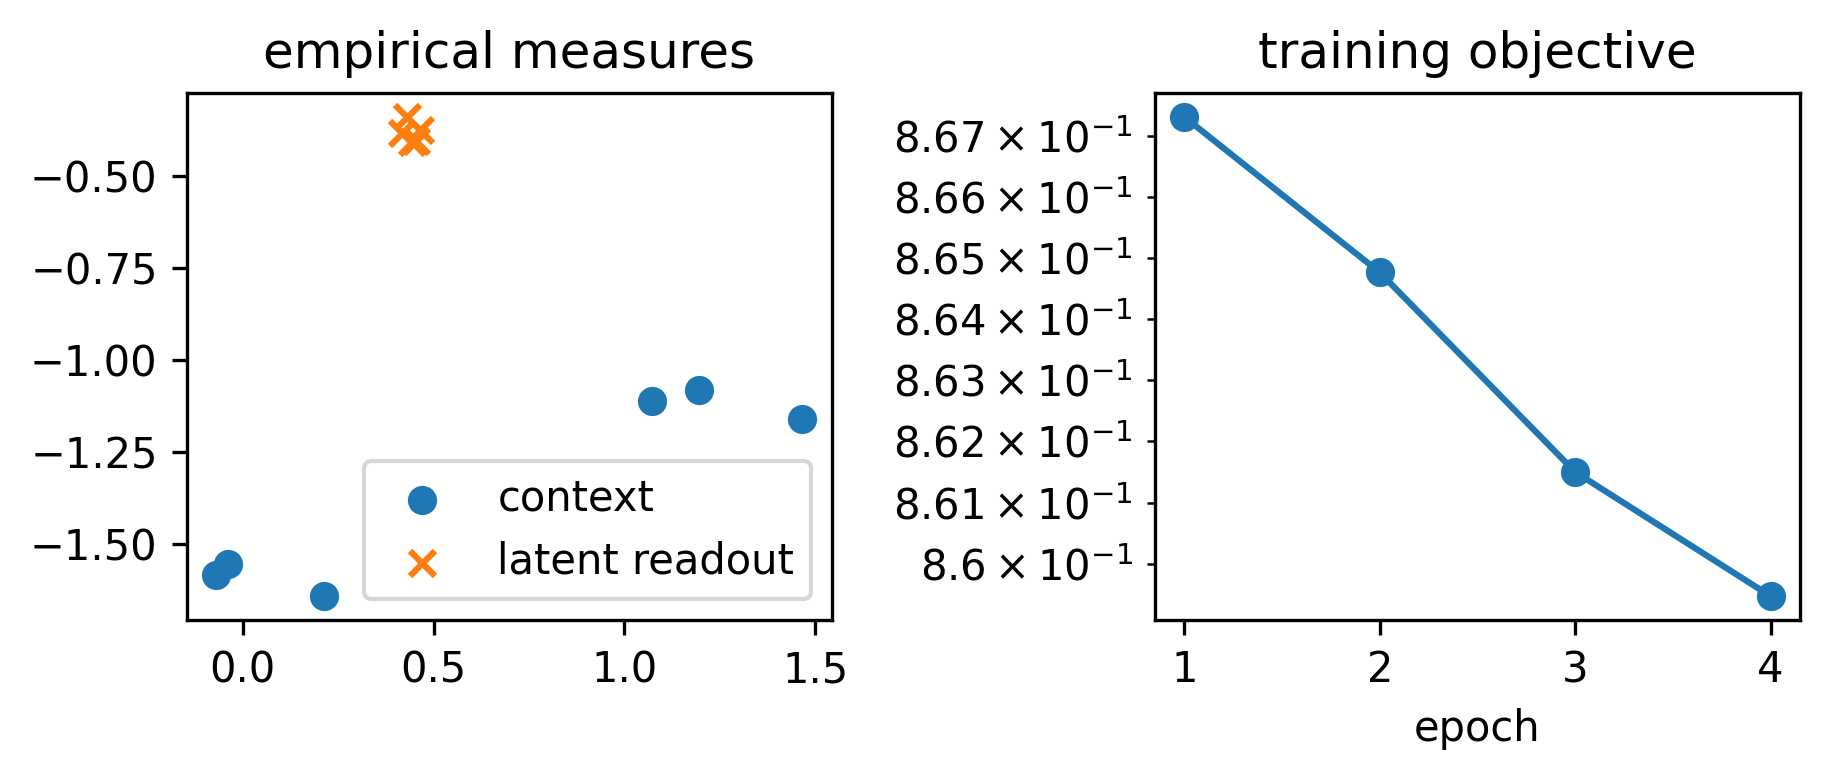

In [7]:
with torch.no_grad():
    final_state = model(data.context[:1], context_mask=data.context_mask[:1])
    decoded = decoder(final_state)[0]
valid_context = data.context[0, data.context_mask[0]]
fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.7))
axes[0].scatter(valid_context[:, 0], valid_context[:, 1], label="context")
axes[0].scatter(decoded[:, 0], decoded[:, 1], marker="x", label="latent readout")
axes[0].legend()
axes[0].set_title("empirical measures")
axes[1].plot(range(1, len(losses) + 1), losses, marker="o")
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_title("training objective")
fig.tight_layout()
plt.show()

## 5. Fixed and Invalid Particles

`latent_mask` identifies valid latent rows. `fixed_mask` is a subset that
remains equal to its initial value during particle descent. This supports
observed anchors or boundary particles without allowing padding rows to enter
the measure.

In [8]:
z0 = torch.randn(1, 5, 4)
latent_mask = torch.tensor([[True, True, True, True, False]])
fixed_mask = torch.tensor([[True, False, False, False, False]])
anchored = model(
    data.context[:1],
    z0=z0,
    context_mask=data.context_mask[:1],
    latent_mask=latent_mask,
    fixed_mask=fixed_mask,
    return_result=True,
)
assert torch.equal(anchored.state[:, 0], z0[:, 0])
assert torch.equal(anchored.state[:, 4], torch.zeros_like(anchored.state[:, 4]))
print("fixed particle preserved and padding excluded")

fixed particle preserved and padding excluded


In [9]:
factory_model = silva_equilibrium_model(
    "silva_distributional_deq",
    input_dim=2,
    latent_dim=4,
    particles=4,
    heads=2,
    max_iter=1,
)
factory_state = factory_model(
    data.context[:1],
    context_mask=data.context_mask[:1],
)
assert factory_state.shape == (1, 4, 4)
print(type(factory_model).__name__)

SILVADistributionalDEQ


## 6. Practical Guidance

| Problem | Diagnostic | Response |
|---|---|---|
| result changes after row permutation | run the EI check | remove positional row encodings and order-dependent pooling |
| padding changes the result | compare variable-length and padded forms | pass masks through attention and discrepancy terms |
| discrepancy oscillates | inspect every descent step | reduce particle step size or change bandwidth |
| task loss is low but measures disagree | report task and measure losses separately | retain an explicit equilibrium diagnostic |

The generated mixtures validate variable-size storage, masks, invariance, and
outer gradients. Reproducing point-cloud benchmarks requires their official
splits, augmentations, sample counts, and task metrics [45].

## Where to Go Next

| Question | Page |
| --- | --- |
| How are variable-size empirical measures generated? | [Dataset-Backed Equilibrium Labs](https://jseluis.github.io/silva-networks/learn/frontier-dataset-labs/#variable-size-empirical-measures) |
| How is the measure objective derived inside SILVA? | [Recent Equilibrium Families](https://jseluis.github.io/silva-networks/learn/frontier-equilibrium-families/#silva-distributional-equilibrium) |
| Which measure dataset objects are public? | [Recent Dataset API](https://jseluis.github.io/silva-networks/api/frontier_data/) |
